In [1]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import warnings, os
import random
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")
SEED = 42

def set_seeds(SEED=42):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seeds(SEED)

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [13]:
DATA_PATH = "network_qoe_latest.csv"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [14]:
COLORS  = ['#2563eb','#dc2626','#16a34a','#d97706','#7c3aed','#0891b2']
config = {
    "SEQ_LEN" : 64,
    "HIDDEN" : 256,
    "LATENT" : 64,
    "LR" : 1e-4,
    "EPOCHS" : 100,
    "PATIENCE" : 12,
    "BATCH" : 256
}

In [15]:
df = pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152071 entries, 0 to 152070
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   run_id                  152071 non-null  object 
 1   timestamp               152071 non-null  float64
 2   datetime                152071 non-null  object 
 3   segment                 152071 non-null  object 
 4   switch_id               152071 non-null  int64  
 5   port_no                 152071 non-null  int64  
 6   mos_voice               152071 non-null  float64
 7   e2e_delay_ms            152071 non-null  float64
 8   plr                     152071 non-null  float64
 9   jitter_ms               152071 non-null  float64
 10  cdr_flag                152071 non-null  int64  
 11  call_setup_time_ms      152071 non-null  float64
 12  buffering_ratio         152071 non-null  float64
 13  rebuffering_freq        152071 non-null  float64
 14  rebuffering_count   

In [16]:
print(f"Manquantes : {df.isna().sum().sum()}")

Manquantes : 43660


In [17]:
print('Distribution des labels :')
print(f'\nTaux anomalie : {(df["label"]!="NORMAL").mean()*100:.1f}%')

Distribution des labels :

Taux anomalie : 68.0%


In [18]:
display(df.describe().round(3))

,timestamp,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,cdr_flag,call_setup_time_ms,buffering_ratio,...,availability,rx_bytes,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count
count,1.520710e+05,152071.0,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,...,152071.000,1.520710e+05,1.520710e+05,152071.000,152071.000,152071.0,152071.0,108411.000,152071.000,152071.000
mean,1.775782e+09,1.0,2.500,3.463,30.848,0.098,3.687,0.183,866.917,0.934,...,0.872,1.351373e+09,1.169727e+09,2562181.508,2232635.078,0.0,0.0,38.204,12.530,5.196
std,2.796161e+04,0.0,1.118,1.187,43.260,0.213,6.434,0.387,1666.359,0.136,...,0.256,1.634543e+09,9.997537e+08,2321319.870,1541676.362,0.0,0.0,46.802,24.878,2.366
min,1.775733e+09,1.0,1.000,1.000,0.000,0.000,0.000,0.000,200.000,0.000,...,0.000,0.000000e+00,0.000000e+00,0.000,0.000,0.0,0.0,4.788,0.000,0.000
25%,1.775758e+09,1.0,1.000,2.549,9.486,0.000,1.066,0.000,304.200,0.907,...,0.925,9.837881e+07,4.167320e+08,588040.000,1007126.000,0.0,0.0,9.514,9.362,4.000
50%,1.775782e+09,1.0,3.000,4.102,13.052,0.011,2.664,0.000,369.100,0.961,...,0.988,7.480894e+08,8.374774e+08,1882755.000,2020733.000,0.0,0.0,19.596,11.427,6.000
75%,1.775806e+09,1.0,4.000,4.391,23.878,0.074,4.141,0.000,671.400,0.995,...,1.000,2.015891e+09,1.632631e+09,4161908.500,3101667.000,0.0,0.0,35.316,13.687,7.000
max,1.775830e+09,1.0,4.000,4.400,3293.902,1.000,408.245,1.000,10000.000,1.000,...,1.000,6.419977e+09,4.097482e+09,8139921.000,6650767.000,0.0,0.0,279.699,3293.902,48.000


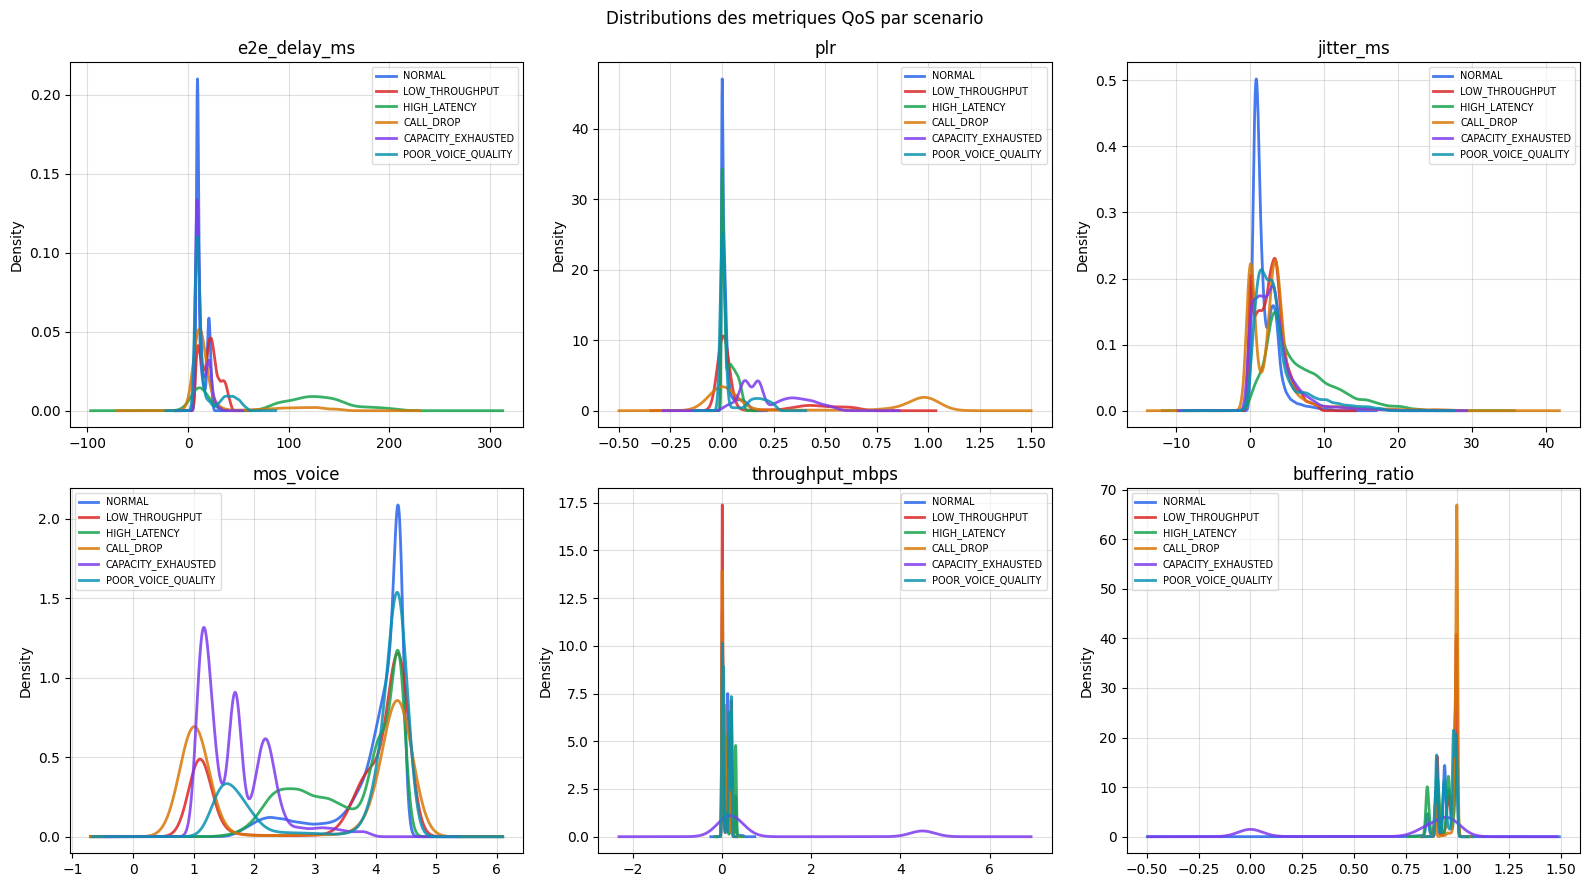

In [20]:
import matplotlib.pyplot as plt
# Distribution des scores de reconstruction selon le label
# Montrer que les metriques QoE separent bien normal vs anomalie
KEY_FEATS = ['e2e_delay_ms','plr','jitter_ms','mos_voice',
             'throughput_mbps','buffering_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distributions des metriques QoS par scenario')
l2c = dict(zip(df['label'].unique(), COLORS))

for ax, feat in zip(axes.flat, KEY_FEATS):
    for lbl, col in l2c.items():
        s = df[df['label']==lbl][feat].dropna()
        s = s[s <= s.quantile(0.99)]
        try: s.plot.kde(ax=ax, label=lbl, color=col, lw=2, alpha=0.85)
        except: pass
    ax.set_title(feat); ax.set_xlabel('')
    ax.legend(fontsize=7, framealpha=0.7); ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

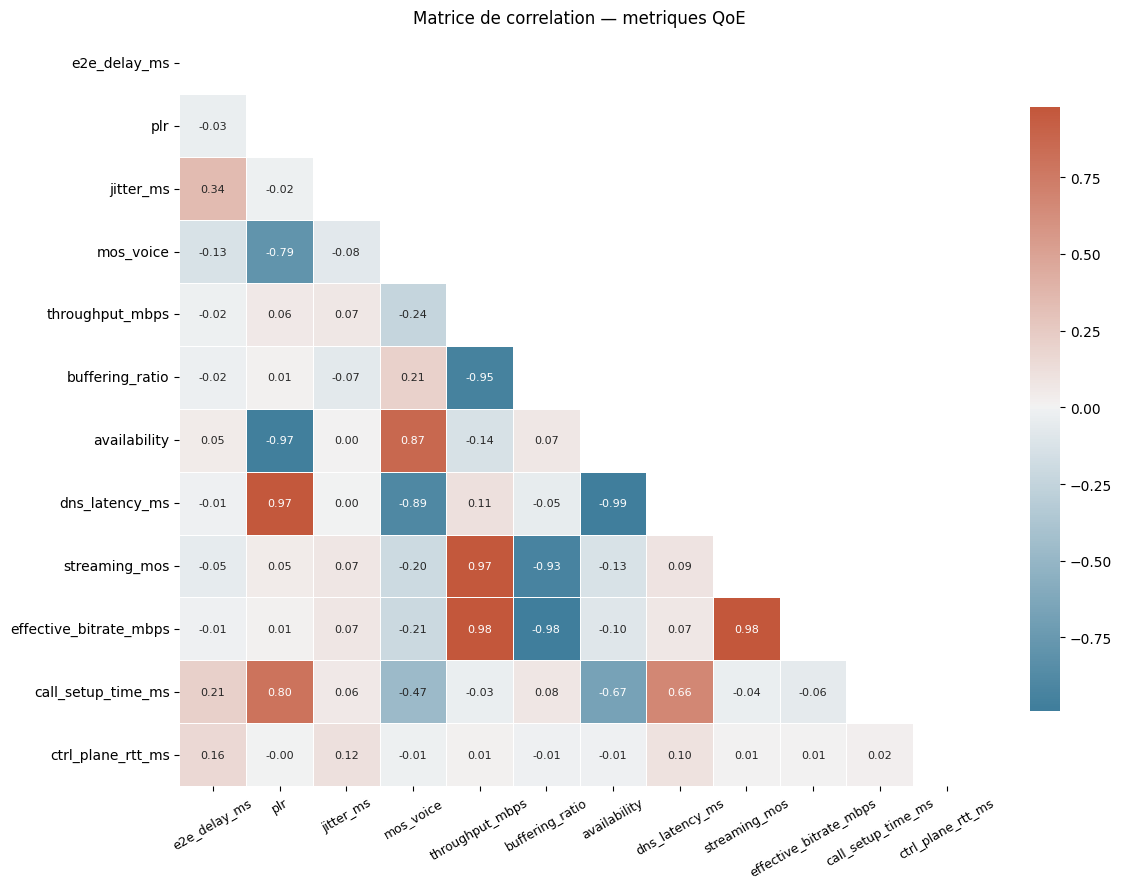

In [22]:
import seaborn as sns
# Matrice de correlation
qoe = ['e2e_delay_ms','plr','jitter_ms','mos_voice','throughput_mbps',
       'buffering_ratio','availability','dns_latency_ms','streaming_mos',
       'effective_bitrate_mbps','call_setup_time_ms','ctrl_plane_rtt_ms']

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df[qoe].corr(), dtype=bool))
sns.heatmap(df[qoe].corr(), mask=mask,
            cmap=sns.diverging_palette(230, 20, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size':8},
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Matrice de correlation — metriques QoE')
for t in ax.get_xticklabels(): t.set_rotation(30); t.set_fontsize(9)
plt.tight_layout()
plt.show()

In [23]:
FEATURES = [
    'e2e_delay_ms', 'plr', 'jitter_ms', 'mos_voice', 'throughput_mbps',
    'buffering_ratio', 'call_setup_time_ms','streaming_mos',
    'ctrl_plane_rtt_ms',
]

In [24]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

y_all = (df['label'] != 'NORMAL').astype(int).values
X_all = df[FEATURES].fillna(0).values

X_normal = X_all[ y_all == 0 ]
y_normal = y_all[y_all == 0]
X_anormal = X_all[ y_all == 1 ]
y_anormal = y_all[y_all == 1]

X_train, X_temp, y_train, y_temp = train_test_split(X_normal,y_normal, test_size=0.3, random_state=SEED)

scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_temp_scaled = scaler.transform(X_temp)
X_anormal_scaled = scaler.transform(X_anormal)

X_eval = np.concatenate((X_anormal_scaled, X_temp_scaled), axis=0)
y_eval = np.concatenate((y_anormal, y_temp), axis=0)

X_val, X_test, y_val, y_test = train_test_split(
    X_eval, y_eval, 
    test_size=0.5, 
    random_state=SEED,
    stratify=y_eval
)

In [25]:
print(f'Features         : {len(FEATURES)}')
print(f'Train (normal)   : {X_train.shape[0]:,}')
print(f'Val   (normal)   : {X_val.shape[0]:,}')
print(f'Test  (all)      : {X_test.shape[0]:,}')
print(f'  dont normal    : {(y_test==0).sum():,}')
print(f'  dont anomalie  : {(y_test==1).sum():,}')

Features         : 9
Train (normal)   : 34,114
Val   (normal)   : 58,978
Test  (all)      : 58,979
  dont normal    : 7,311
  dont anomalie  : 51,668


In [26]:
def youden_threshold(y_true, scores):
    """
    Seuil optimal de Youden : maximise TPR - FPR sur la courbe ROC.
    Approche utilisee dans le notebook NVIDIA.
    """
    fpr_v, tpr_v, thresholds = roc_curve(y_true, scores)
    J       = tpr_v - fpr_v
    best_i  = np.argmax(J)
    return float(thresholds[best_i])


def evaluate(name, y_true, scores, threshold):
    """Calcule toutes les metriques de classification."""
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        'name':       name,
        'threshold':  round(threshold, 4),
        'Accuracy':   accuracy_score(y_true, preds),
        'Recall':     recall_score(y_true, preds, zero_division=0),
        'Precision':  precision_score(y_true, preds, zero_division=0),
        'F1':         f1_score(y_true, preds, zero_division=0),
        'FPR':        fp / (fp+tn) if (fp+tn)>0 else 0.0,
        'AUC':        roc_auc_score(y_true, scores),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'scores': scores,
        'preds':  preds,
    }


def plot_cm(r, ax):
    """Matrice de confusion avec metriques."""
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomalie'])
    ax.set_yticklabels(['Normal', 'Anomalie'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=10, fontweight='bold')
    ax.set_xlabel('Predit'); ax.set_ylabel('Reel')
    ax.set_title(
        f"{r['name']}\n"
        f"Acc={r['Accuracy']*100:.1f}%  F1={r['F1']:.3f}  AUC={r['AUC']:.3f}"
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def plot_recon_dist(ax, scores, y_true, threshold, title):
    """
    Distribution des scores de reconstruction (approche NVIDIA Section 3).
    Montre la separation entre normal et anomalie.
    """
    bins = np.linspace(0, 1, 80)
    ax.hist(scores[y_true==0], bins=bins, color='#2563eb', alpha=0.6,
            label='Normal', density=True)
    ax.hist(scores[y_true==1], bins=bins, color='#dc2626', alpha=0.6,
            label='Anomalie', density=True)
    ax.axvline(threshold, color='black', ls='--', lw=2,
               label=f'Seuil Youden={threshold:.3f}')
    ax.set_title(title); ax.set_xlabel('Score de reconstruction')
    ax.set_ylabel('Densite'); ax.legend(fontsize=9); ax.grid(alpha=0.4)


all_results = {}

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
# Entraine sur donnees NORMALES uniquement
iso = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_scaled)

scores_val = -iso.decision_function(X_val)
scores_val = (scores_val - scores_val.min()) / (scores_val.max() - scores_val.min() + 1e-9)
thr_iso = youden_threshold(y_val, scores_val)  # threshold tuned on val

scores_test = -iso.decision_function(X_test)
scores_test = (scores_test - scores_test.min()) / (scores_test.max() - scores_test.min() + 1e-9)
r_iso = evaluate('Isolation Forest', y_test, scores_test, thr_iso)

all_results['Isolation Forest'] = r_iso

print(f'Seuil Youden  : {thr_iso:.4f}')
print(f'Accuracy      : {r_iso["Accuracy"]*100:.2f}%')
print(f'Recall        : {r_iso["Recall"]*100:.2f}%')
print(f'Precision     : {r_iso["Precision"]*100:.4f}%')
print(f'F1 Score      : {r_iso["F1"] * 100:.4f}%')
print(f'FPR           : {r_iso["FPR"]*100:.2f}%')
print(f'AUC-ROC       : {r_iso["AUC"] * 100:.4f}%')

Seuil Youden  : 0.3228
Accuracy      : 61.69%
Recall        : 57.49%
Precision     : 97.9166%
F1 Score      : 72.4437%
FPR           : 8.64%
AUC-ROC       : 75.3694%


In [29]:
class BiLSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=config["HIDDEN"], latent=config["LATENT"]):
        super().__init__()
        self.encoder = nn.LSTM(n_feat, hidden, batch_first=True, bidirectional=True)
        self.enc_fc  = nn.Sequential(nn.Linear(2*hidden, latent), nn.ReLU())
        self.decoder = nn.LSTM(latent, hidden, batch_first=True)
        self.dec_fc  = nn.Linear(hidden, n_feat)

    def forward(self, x):
        _, (h, _) = self.encoder(x)                        # h: (2, B, H)
        h_cat = torch.cat([h[0], h[1]], dim=1)             # (B, 2H)
        z   = self.enc_fc(h_cat)                           # (B, latent)
        z_r = z.unsqueeze(1).expand(-1, x.size(1), -1)
        out, _ = self.decoder(z_r)
        return self.dec_fc(out)
        
def make_sequences(X, seq_len, stride=None):
    """Decoupage en sequences glissantes."""
    if stride is None: stride = seq_len // 2
    seqs   = [X[i:i+seq_len] for i in range(0, len(X)-seq_len+1, stride)]
    starts = [i for i in range(0, len(X)-seq_len+1, stride)]
    return np.array(seqs), np.array(starts)


def train_ae(model, X_train, X_val, config):
    """
    Entraine un autoencoder PyTorch sur donnees normales avec early stopping.
    Retourne (model, train_losses, val_losses).
    """
    set_seeds(SEED)
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=config["LR"])
    loss_fn = nn.MSELoss()

    seqs_tr, _ = make_sequences(X_train, config["SEQ_LEN"])
    seqs_va, _ = make_sequences(X_val,   config["SEQ_LEN"])

    Xt = torch.FloatTensor(seqs_tr).to(DEVICE)
    Xv = torch.FloatTensor(seqs_va).to(DEVICE)

    g = torch.Generator()
    g.manual_seed(SEED)
    
    loader = DataLoader(TensorDataset(Xt, Xt), batch_size=config["BATCH"], shuffle=True, worker_init_fn=seed_worker,generator=g )

    best_loss, best_state, patience_cnt = float('inf'), None, 0
    tr_hist, vl_hist = [], []

    for ep in range(1, config["EPOCHS"]+1):
        model.train(); ep_loss = 0.0
        for xb, _ in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)

        model.eval()
        with torch.no_grad():
            vl_loss = loss_fn(model(Xv), Xv).item()

        tr_hist.append(ep_loss); vl_hist.append(vl_loss)

        if vl_loss < best_loss - 1e-6:
            best_loss      = vl_loss
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt   = 0
        else:
            patience_cnt  += 1

        if ep % 10 == 0:
            print(f'  Epoch {ep:3d}/{config["EPOCHS"]} | train={ep_loss:.5f} | val={vl_loss:.5f} | patience={patience_cnt}/{config["PATIENCE"]}')

        if patience_cnt >= config["PATIENCE"]:
            print(f'  => Early stopping @ epoch {ep} | best val={best_loss:.5f}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return model.to('cpu'), tr_hist, vl_hist


def recon_scores(model, X, seq_len=config["SEQ_LEN"]):
    """
    Calcule les scores de reconstruction pour chaque sample.
    Score = moyenne des MSE des sequences contenant ce sample.
    """
    stride = seq_len // 2
    seqs, starts = make_sequences(X, seq_len, stride)
    model.eval()
    err_sum = np.zeros(len(X)); err_cnt = np.zeros(len(X))

    with torch.no_grad():
        for b in range(0, len(seqs), 512):
            batch  = torch.FloatTensor(seqs[b:b+512])
            recon  = model(batch).numpy()
            mse    = np.mean((seqs[b:b+512] - recon)**2, axis=(1, 2))
            for k, err in enumerate(mse):
                s = starts[b+k]; e = min(s+seq_len, len(X))
                err_sum[s:e] += err; err_cnt[s:e] += 1

    err_cnt = np.where(err_cnt == 0, 1, err_cnt)
    raw     = err_sum / err_cnt
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

In [30]:
print('=== BiLSTM Autoencoder ===')
bilstm_m = BiLSTMAutoencoder(n_feat=len(FEATURES))
bilstm_m, bilstm_tr, bilstm_vl = train_ae(bilstm_m, X_train_scaled, X_val, config)

sc_bilstm_val = recon_scores(bilstm_m, X_val)
thr_b = youden_threshold(y_val, sc_bilstm_val)

# --- Test : final evaluation ---
sc_bilstm_test = recon_scores(bilstm_m, X_test)
r_bilstm = evaluate('BiLSTM AE', y_test, sc_bilstm_test, thr_b)

all_results['BiLSTM AE'] = r_bilstm

print(f'Seuil Youden  : {thr_b:.4f}')
print(f'Accuracy      : {r_bilstm["Accuracy"]*100:.2f}%')
print(f'Recall        : {r_bilstm["Recall"]*100:.2f}%')
print(f'Precision     : {r_bilstm["Precision"]*100:.4f}%')
print(f'F1 Score      : {r_bilstm["F1"]*100:.4f}%')
print(f'FPR           : {r_bilstm["FPR"]*100:.2f}%')
print(f'AUC-ROC       : {r_bilstm["AUC"]*100:.4f}%')

=== BiLSTM Autoencoder ===
  Epoch  10/100 | train=8.60527 | val=72.63139 | patience=0/12
  Epoch  20/100 | train=14.83072 | val=72.76315 | patience=10/12
  => Early stopping @ epoch 22 | best val=72.63139
Seuil Youden  : 0.1468
Accuracy      : 51.00%
Recall        : 51.14%
Precision     : 87.8424%
F1 Score      : 64.6450%
FPR           : 50.02%
AUC-ROC       : 50.7705%
